# 02 (v2) — Forecast projection from the v2 marketing CSV (CSV-only, no hybrid)

Mirrors `02_forecast_projection.ipynb` but consumes the **2026-05-20 v2 CSV** instead of the v1 (2026-05-19) one.

**Key differences from v1 02:**
- Source CSV: `paid_dau_weekly_forecast.v2_model.20260520.csv` (columns: `paid_dau_gt_1yr`, `paid_dau_lte_12mo`, `total_paid_dau`).
- Validation target switched to **Fenix Android gap** (`country='ALL', app_name='fenix_android'`), not the ALL-MOBILE rollup. The v1 notebook used ALL-MOBILE which understates the Fenix-attributable target by ~45k DAU — see [[project-fenix-gap-target]].
- Anchor still 2026-03-30 (Monday before campaign launch). We can re-tune later if the residual demands it.

Goal: see how well a pure CSV-derived lift series matches the empirical Fenix gap **without** any hybrid stitch.


In [1]:
# [setup]
import hashlib
import json
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths
SOURCE_CSV = Path('data/paid_dau_weekly_forecast.v2_model.20260520.csv')
OUT_PARQUET = Path('data/marketing_lift_model.real_data_v2.2026-05-20.parquet')
OUT_META = Path('data/marketing_lift_model.real_data_v2.2026-05-20.meta.json')

# Forecasts used for validation (mobile rollup, ex-Iran via filter)
APRIL_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/'
    'mobile_cps0.02_thresh32_recent13_clip0.6/'
    'mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
)
JUNE_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/'
    'mobile_cps0.02_thresh32_recent13_clip0.6_cap426/'
    'mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'
)

# Dates
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')
# Anchor where lift = 0. Same Option-B "soft launch" framing as v1 (2026-03-30,
# Monday before launch). We may re-tune for v2 if the residual demands it.
ANCHOR_DATE = pd.Timestamp('2026-03-30')
LAST_HISTORICAL_DATE = pd.Timestamp('2026-05-20')  # CSV generation date
PARQUET_START = pd.Timestamp('2026-02-01')
PARQUET_END = pd.Timestamp('2026-12-31')
BASELINE_START = pd.Timestamp('2026-02-01')
BASELINE_END = pd.Timestamp('2026-03-28')

MA_WINDOW = 28

# Easter mask — same dates as v1 (Easter Sunday 2026-04-05, Orthodox 2026-04-19)
EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
    [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
    [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
)))


def _load_forecast(path):
    df = pd.read_parquet(path)
    df['target_date'] = pd.to_datetime(df['target_date'])
    return df


def _aggregate(df, country, app_name, data_type_filter=None):
    rollup = df[(df['data_source'] == 'glean_mobile')
                & (df['country'] == country)
                & (df['app_name'] == app_name)
                & (df['segment'] == '{}')].copy()
    if data_type_filter is not None:
        rollup = rollup[rollup['data_type'] == data_type_filter]
    return rollup.set_index('target_date').sort_index()['dau']


In [2]:
# [load-csv]
# Read v2 CSV directly. The CSV has comma-thousands formatting and an ISO
# datetime in the `week` column. We only need `week` and `total_paid_dau` for
# the lift model — the gt_1yr / lte_12mo split is informational.

weekly_raw = pd.read_csv(SOURCE_CSV, thousands=',')
weekly_raw['week'] = pd.to_datetime(weekly_raw['week'])
weekly = (weekly_raw[['week', 'paid_dau_gt_1yr', 'paid_dau_lte_12mo', 'total_paid_dau']]
          .rename(columns={'week': 'week_starting'})
          .sort_values('week_starting')
          .reset_index(drop=True))

assert (weekly['week_starting'].dt.dayofweek == 0).all(), 'all weeks must be Mondays'

print(f'Loaded {len(weekly)} weekly rows from {SOURCE_CSV.name}')
print(f'Date range: {weekly["week_starting"].min().date()} → {weekly["week_starting"].max().date()}')
print()
print('Anchor week:')
anchor_row = weekly[weekly['week_starting'] == ANCHOR_DATE].iloc[0]
print(f'  week_starting    = {anchor_row["week_starting"].date()}')
print(f'  paid_dau_gt_1yr  = {anchor_row["paid_dau_gt_1yr"]:>10,}')
print(f'  paid_dau_lte_12mo= {anchor_row["paid_dau_lte_12mo"]:>10,}')
print(f'  total_paid_dau   = {anchor_row["total_paid_dau"]:>10,}')
print()
print('Year-end (Dec-28) week, for reference:')
ye = weekly.iloc[-1]
print(f'  total_paid_dau   = {ye["total_paid_dau"]:>10,}')


Loaded 52 weekly rows from paid_dau_weekly_forecast.v2_model.20260520.csv
Date range: 2026-01-05 → 2026-12-28

Anchor week:
  week_starting    = 2026-03-30
  paid_dau_gt_1yr  =    185,548
  paid_dau_lte_12mo=    833,967
  total_paid_dau   =  1,019,515

Year-end (Dec-28) week, for reference:
  total_paid_dau   =  1,374,596


In [3]:
# [interpolate-daily]
# Linear interpolation between Monday anchors. Same snapshot-interpretation
# convention as v1: each weekly value is treated as the daily DAU level at
# that Monday (verified against BQ in v1 work to within ~3%).

weekly_indexed = weekly.set_index('week_starting')['total_paid_dau'].astype('float64')

daily_index = pd.date_range(weekly_indexed.index.min(), weekly_indexed.index.max(), freq='D')
daily_paid = weekly_indexed.reindex(daily_index).interpolate(method='linear', limit_area='inside')

# Forward-fill the 3 trailing days after the last Monday (2026-12-28 → 2026-12-31).
extended_index = pd.date_range(daily_paid.index.min(), PARQUET_END, freq='D')
daily_paid = daily_paid.reindex(extended_index).ffill()

print(f'Daily series coverage: {daily_paid.index.min().date()} → {daily_paid.index.max().date()}')
print(f'NaN count: {daily_paid.isna().sum()}')
print()
print('Daily snapshot:')
for d in [pd.Timestamp('2026-01-05'),
          pd.Timestamp('2026-03-30'),
          pd.Timestamp('2026-04-06'),
          pd.Timestamp('2026-05-18'),
          pd.Timestamp('2026-07-01'),
          pd.Timestamp('2026-12-15'),
          PARQUET_END]:
    print(f'  {d.date()}  {daily_paid.loc[d]:>10,.0f}')


Daily series coverage: 2026-01-05 → 2026-12-31
NaN count: 0

Daily snapshot:
  2026-01-05     844,764
  2026-03-30   1,019,515
  2026-04-06   1,053,915
  2026-05-18   1,324,641
  2026-07-01   1,419,062
  2026-12-15   1,365,112
  2026-12-31   1,374,596


In [4]:
# [anchor-at-launch]
# Lift = total_paid_dau(t) − total_paid_dau(ANCHOR_DATE). Pre-launch days
# clipped to 0 — the campaign hadn't started yet.

anchor_value = float(daily_paid.loc[ANCHOR_DATE])
lift_raw = daily_paid - anchor_value
marketing_lift_daily = lift_raw.where(lift_raw.index >= ANCHOR_DATE, 0.0).copy()
marketing_lift_daily.name = 'marketing_lift_daily'

print(f'Anchor value (total_paid_dau at {ANCHOR_DATE.date()}): {anchor_value:>14,.0f}')
print()
print('Marketing lift snapshot (daily values):')
print(f'  {"date":>10}  {"lift_daily":>14}')
for d in [pd.Timestamp('2026-03-01'),
          pd.Timestamp('2026-04-05'),
          ANCHOR_DATE,
          pd.Timestamp('2026-05-01'),
          LAST_HISTORICAL_DATE,
          pd.Timestamp('2026-07-01'),
          pd.Timestamp('2026-09-01'),
          pd.Timestamp('2026-12-15'),
          PARQUET_END]:
    if d in marketing_lift_daily.index:
        print(f'  {d.date()}  {marketing_lift_daily.loc[d]:>+14,.0f}')

assert marketing_lift_daily.loc[ANCHOR_DATE] == 0.0
assert (marketing_lift_daily.loc[:ANCHOR_DATE - pd.Timedelta(days=1)] == 0.0).all()


Anchor value (total_paid_dau at 2026-03-30):      1,019,515

Marketing lift snapshot (daily values):
        date      lift_daily
  2026-03-01              +0
  2026-04-05         +29,486
  2026-03-30              +0
  2026-05-01        +167,919
  2026-05-20        +316,233
  2026-07-01        +399,547
  2026-09-01        +352,730
  2026-12-15        +345,597
  2026-12-31        +355,081


In [5]:
# [pad-to-coverage]
# Extend backward to PARQUET_START (2026-02-01). Pre-CSV days are pre-launch,
# get 0.

full_index = pd.date_range(PARQUET_START, PARQUET_END, freq='D')
marketing_lift_daily = marketing_lift_daily.reindex(full_index, fill_value=0.0)
marketing_lift_daily.name = 'marketing_lift_daily'

assert marketing_lift_daily.isna().sum() == 0
assert marketing_lift_daily.index.min() == PARQUET_START
assert marketing_lift_daily.index.max() == PARQUET_END

print(f'Daily lift series coverage: {marketing_lift_daily.index.min().date()} → {marketing_lift_daily.index.max().date()}')
print(f'Rows: {len(marketing_lift_daily)}  (expected: 334)')


Daily lift series coverage: 2026-02-01 → 2026-12-31
Rows: 334  (expected: 334)


In [6]:
# [compute-ma]
marketing_lift_ma = (marketing_lift_daily
                     .rolling(window=MA_WINDOW, min_periods=14)
                     .mean()
                     .rename('marketing_lift_ma'))

print(f'MA28 series coverage: {marketing_lift_ma.index.min().date()} → {marketing_lift_ma.index.max().date()}')
print(f'First non-NaN: {marketing_lift_ma.first_valid_index().date()}')
print()
print('MA28 snapshot:')
print(f'  {"date":>10}  {"daily":>14}  {"ma28":>14}')
for d in [ANCHOR_DATE,
          pd.Timestamp('2026-05-01'),
          LAST_HISTORICAL_DATE,
          pd.Timestamp('2026-07-01'),
          pd.Timestamp('2026-09-01'),
          pd.Timestamp('2026-12-15'),
          PARQUET_END]:
    daily_val = marketing_lift_daily.loc[d]
    ma_val = marketing_lift_ma.loc[d]
    daily_str = f'{daily_val:>+14,.0f}'
    ma_str = f'{ma_val:>+14,.0f}' if pd.notna(ma_val) else f'{"NaN":>14}'
    print(f'  {d.date()}  {daily_str}  {ma_str}')


MA28 series coverage: 2026-02-01 → 2026-12-31
First non-NaN: 2026-02-14

MA28 snapshot:
        date           daily            ma28
  2026-03-30              +0              +0
  2026-05-01        +167,919        +100,584
  2026-05-20        +316,233        +221,112
  2026-07-01        +399,547        +433,816
  2026-09-01        +352,730        +354,279
  2026-12-15        +345,597        +349,558
  2026-12-31        +355,081        +349,335


In [7]:
# [load-fenix-gap]
# Validation target: Fenix Android gap = (June actuals − April mktg-off forecast)
# at country='ALL', app_name='fenix_android'. This is the right empirical
# reference for a Fenix-only campaign — iOS / Focus errors are uncorrelated with
# marketing and would dilute the signal in an ALL-MOBILE rollup.

april = _load_forecast(APRIL_FORECAST_PATH)
june = _load_forecast(JUNE_FORECAST_PATH)

april_fenix = _aggregate(april, country='ALL', app_name='fenix_android')
actuals_fenix = _aggregate(june, country='ALL', app_name='fenix_android', data_type_filter='training')

gap_index = april_fenix.index.intersection(actuals_fenix.index)
fenix_gap_daily = (actuals_fenix.reindex(gap_index)
                   - april_fenix.reindex(gap_index)).rename('fenix_gap_daily')
fenix_gap_ma = (fenix_gap_daily
                .rolling(window=MA_WINDOW, min_periods=14)
                .mean()
                .rename('fenix_gap_ma'))

training_end_actual = actuals_fenix.dropna().index.max()
print(f'April Fenix forecast: {len(april_fenix):>5} rows, '
      f'{april_fenix.index.min().date()} → {april_fenix.index.max().date()}')
print(f'June Fenix actuals (training): {len(actuals_fenix):>5} rows, '
      f'{actuals_fenix.index.min().date()} → {actuals_fenix.index.max().date()}')
print(f'Gap coverage: {fenix_gap_daily.index.min().date()} → {fenix_gap_daily.index.max().date()}')
print(f'Training end: {training_end_actual.date()}')
print()
print('Daily gap stats (post-launch):')
post = fenix_gap_daily.loc[CAMPAIGN_LAUNCH:training_end_actual]
print(f'  N days:   {len(post)}')
print(f'  Mean:     {post.mean():>+10,.0f}')
print(f'  Std:      {post.std():>+10,.0f}')
print(f'  Min:      {post.min():>+10,.0f}  at {post.idxmin().date()}')
print(f'  Max:      {post.max():>+10,.0f}  at {post.idxmax().date()}')


April Fenix forecast:  2556 rows, 2021-01-01 → 2027-12-31
June Fenix actuals (training):  1962 rows, 2021-01-01 → 2026-05-16
Gap coverage: 2021-01-01 → 2026-05-16
Training end: 2026-05-16

Daily gap stats (post-launch):
  N days:   41
  Mean:       +332,450
  Std:        +130,327
  Min:          -3,985  at 2026-04-06
  Max:        +591,504  at 2026-05-14


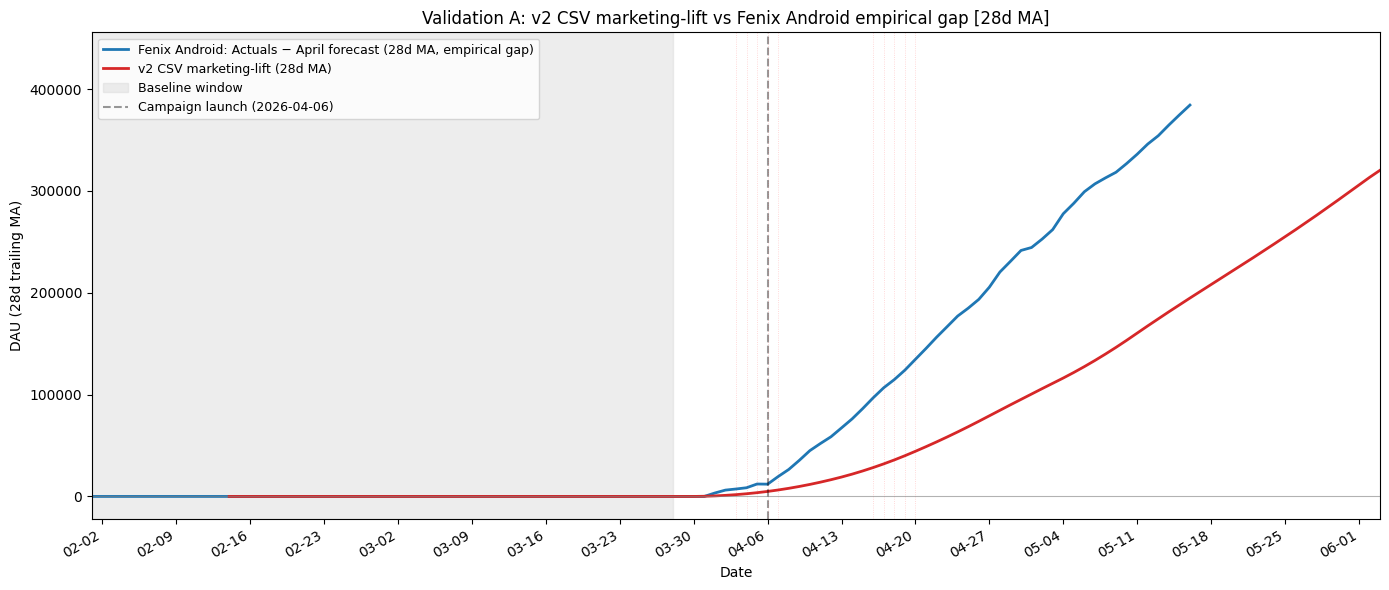

Validation A — residual (v2 marketing_lift_ma − fenix_gap_ma), post-launch non-Easter days:
  N days:                            34
  Fenix gap MA mean (post-launch):         +218,144 DAU
  v2 lift MA mean (post-launch):            +93,045 DAU
  Residual mean (lift − gap):              -125,099 DAU  (undershoot)
  Residual std:                             +54,313 DAU
  Residual RMSE:                           +136,062 DAU


In [8]:
# [validation-a-fit]
# How closely does the v2 CSV-derived marketing_lift_ma match the empirical
# Fenix gap_ma over the post-campaign window (non-Easter, MA valid)?

ma_compare_index = fenix_gap_ma.index.intersection(marketing_lift_ma.index)
compare_mask = (
    (ma_compare_index >= CAMPAIGN_LAUNCH)
    & (~ma_compare_index.isin(EASTER_MASK_DATES))
    & fenix_gap_ma.reindex(ma_compare_index).notna()
    & marketing_lift_ma.reindex(ma_compare_index).notna()
)
compare_dates = ma_compare_index[compare_mask]

fenix_gap_ma_mean_post = fenix_gap_ma.reindex(compare_dates).mean()
marketing_lift_ma_mean_post = marketing_lift_ma.reindex(compare_dates).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(fenix_gap_ma.index, fenix_gap_ma, '-', linewidth=2, color='C0',
        label='Fenix Android: Actuals − April forecast (28d MA, empirical gap)')
ax.plot(marketing_lift_ma.index, marketing_lift_ma, '-', linewidth=2, color='C3',
        label='v2 CSV marketing-lift (28d MA)')

ax.axvspan(BASELINE_START, BASELINE_END, color='lightgrey', alpha=0.4,
           label='Baseline window')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')
for day in EASTER_MASK_DATES:
    ax.axvline(day, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)

ax.set_title('Validation A: v2 CSV marketing-lift vs Fenix Android empirical gap [28d MA]')
ax.set_ylabel('DAU (28d trailing MA)')
ax.set_xlabel('Date')
ax.set_xlim(BASELINE_START, LAST_HISTORICAL_DATE + pd.Timedelta(days=14))
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

a_residuals = (marketing_lift_ma - fenix_gap_ma).reindex(compare_dates)
a_residual_mean = float(a_residuals.mean())
a_residual_std = float(a_residuals.std())
a_residual_rmse = float(np.sqrt((a_residuals ** 2).mean()))

print(f'Validation A — residual (v2 marketing_lift_ma − fenix_gap_ma), post-launch non-Easter days:')
print(f'  N days:                            {len(a_residuals)}')
print(f'  Fenix gap MA mean (post-launch):   {fenix_gap_ma_mean_post:>+14,.0f} DAU')
print(f'  v2 lift MA mean (post-launch):     {marketing_lift_ma_mean_post:>+14,.0f} DAU')
print(f'  Residual mean (lift − gap):        {a_residual_mean:>+14,.0f} DAU  '
      f'({"over" if a_residual_mean > 0 else "under"}shoot)')
print(f'  Residual std:                      {a_residual_std:>+14,.0f} DAU')
print(f'  Residual RMSE:                     {a_residual_rmse:>+14,.0f} DAU')


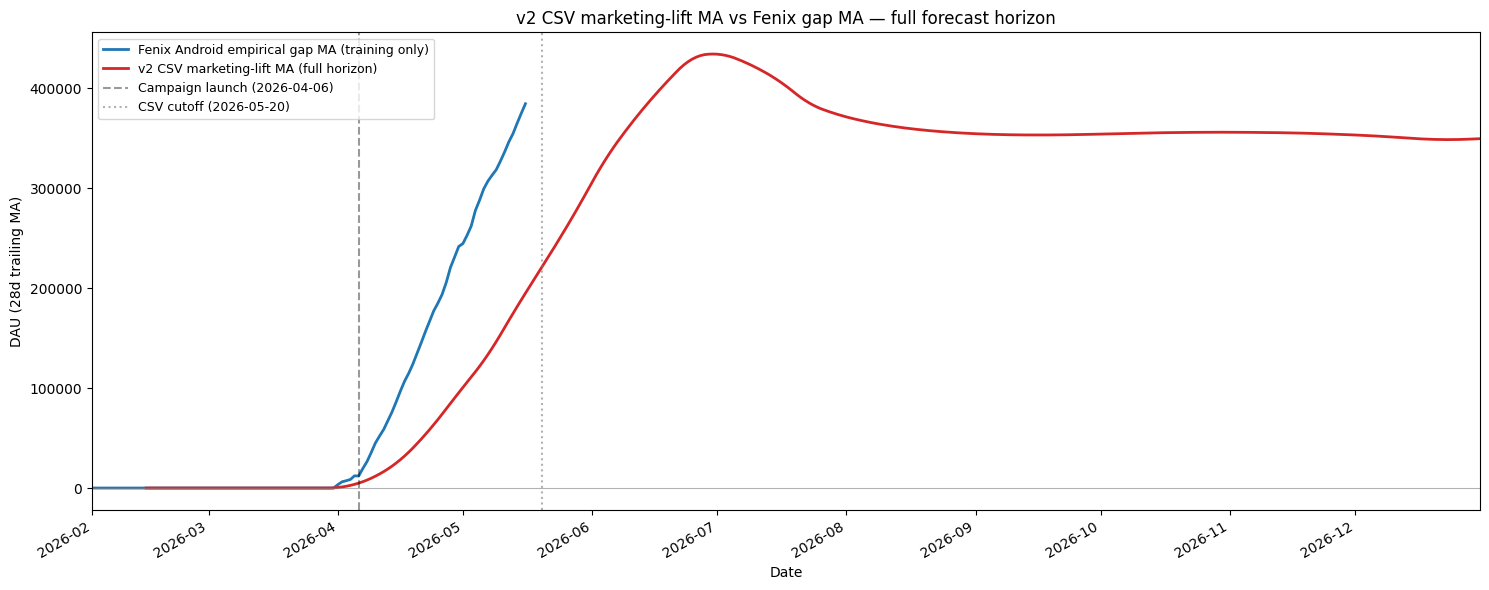

Year-end (Dec-15) MA value:
  v2 CSV marketing-lift MA:       +349,558


In [9]:
# [full-overlay]
# Full-horizon view: lift MA through year-end, with the Fenix gap MA overlaid
# while it exists.

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(fenix_gap_ma.index, fenix_gap_ma, '-', linewidth=2, color='C0',
        label='Fenix Android empirical gap MA (training only)')
ax.plot(marketing_lift_ma.index, marketing_lift_ma, '-', linewidth=2, color='C3',
        label='v2 CSV marketing-lift MA (full horizon)')

ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')
ax.axvline(LAST_HISTORICAL_DATE, color='grey', linestyle=':', alpha=0.6,
           label=f'CSV cutoff ({LAST_HISTORICAL_DATE.date()})')
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)

ax.set_title('v2 CSV marketing-lift MA vs Fenix gap MA — full forecast horizon')
ax.set_ylabel('DAU (28d trailing MA)')
ax.set_xlabel('Date')
ax.set_xlim(BASELINE_START, PARQUET_END)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print('Year-end (Dec-15) MA value:')
print(f'  v2 CSV marketing-lift MA: {marketing_lift_ma.loc[pd.Timestamp("2026-12-15")]:>+14,.0f}')


In [10]:
# [build-export-df]
export_df = pd.DataFrame({
    'date': marketing_lift_daily.index,
    'marketing_lift_daily': marketing_lift_daily.values,
    'marketing_lift_ma': marketing_lift_ma.values,
})
assert export_df['date'].is_monotonic_increasing
assert export_df['date'].min() == PARQUET_START
assert export_df['date'].max() == PARQUET_END
assert len(export_df) == 334
print(f'Export DF: {len(export_df)} rows, '
      f'{export_df["date"].min().date()} → {export_df["date"].max().date()}')
print(export_df.head(3).to_string(index=False))
print('...')
print(export_df.tail(3).to_string(index=False))


Export DF: 334 rows, 2026-02-01 → 2026-12-31
      date  marketing_lift_daily  marketing_lift_ma
2026-02-01                   0.0                NaN
2026-02-02                   0.0                NaN
2026-02-03                   0.0                NaN
...
      date  marketing_lift_daily  marketing_lift_ma
2026-12-29              355081.0      348954.061224
2026-12-30              355081.0      349136.897959
2026-12-31              355081.0      349335.081633


In [11]:
# [write-artifact]
OUT_PARQUET.parent.mkdir(exist_ok=True)
export_df.to_parquet(OUT_PARQUET, index=False)
print(f'Wrote {OUT_PARQUET} ({OUT_PARQUET.stat().st_size:,} bytes)')

source_sha1 = hashlib.sha1(SOURCE_CSV.read_bytes()).hexdigest()
artifact_sha1 = hashlib.sha1(OUT_PARQUET.read_bytes()).hexdigest()
print(f'Source CSV sha1:   {source_sha1}')
print(f'Artifact sha1:     {artifact_sha1}')


Wrote data/marketing_lift_model.real_data_v2.2026-05-20.parquet (9,287 bytes)
Source CSV sha1:   caa21c51c79537d850f6e2c35d98ff176587f4f3
Artifact sha1:     d9c6ffd2499541017c74f33347405f80883ff2c7


In [12]:
# [write-meta]
git_hash = subprocess.check_output(
    ['git', '-C', str(Path('.').resolve()), 'rev-parse', 'HEAD']
).decode().strip()

meta = {
    'model_name': 'real_data_v2_csv_only',
    'model_description': (
        'CSV-only marketing-lift model derived from the v2 paid-DAU CSV '
        '(2026-05-20). Lift = total_paid_dau(t) − total_paid_dau(ANCHOR_DATE), '
        'linearly interpolated from weekly Monday anchors and clipped to 0 '
        'pre-launch. No hybrid stitch.'
    ),
    'created_at_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'git_commit': git_hash,
    'sources': {
        'csv_path': str(SOURCE_CSV),
        'csv_sha1': source_sha1,
        'csv_generation_date': str(LAST_HISTORICAL_DATE.date()),
    },
    'parameters': {
        'anchor_date': str(ANCHOR_DATE.date()),
        'campaign_launch': str(CAMPAIGN_LAUNCH.date()),
        'parquet_start': str(PARQUET_START.date()),
        'parquet_end': str(PARQUET_END.date()),
        'ma_window': MA_WINDOW,
    },
    'validation': {
        'target': 'fenix_android_gap',
        'window': f'{CAMPAIGN_LAUNCH.date()} → training_end',
        'easter_masked': True,
        'n_days': int(len(a_residuals)),
        'fenix_gap_ma_mean_post': float(fenix_gap_ma_mean_post),
        'lift_ma_mean_post': float(marketing_lift_ma_mean_post),
        'residual_mean': float(a_residual_mean),
        'residual_std': float(a_residual_std),
        'residual_rmse': float(a_residual_rmse),
    },
    'output': {
        'parquet_path': str(OUT_PARQUET),
        'parquet_sha1': artifact_sha1,
        'rows': int(len(export_df)),
    },
}

OUT_META.write_text(json.dumps(meta, indent=2))
print(f'Wrote {OUT_META}')
print()
print(json.dumps(meta, indent=2))


Wrote data/marketing_lift_model.real_data_v2.2026-05-20.meta.json

{
  "model_name": "real_data_v2_csv_only",
  "model_description": "CSV-only marketing-lift model derived from the v2 paid-DAU CSV (2026-05-20). Lift = total_paid_dau(t) \u2212 total_paid_dau(ANCHOR_DATE), linearly interpolated from weekly Monday anchors and clipped to 0 pre-launch. No hybrid stitch.",
  "created_at_utc": "2026-05-20T18:51:08+00:00",
  "git_commit": "0c4c3fdf9651c4dc728ad7c958009b30e692302f",
  "sources": {
    "csv_path": "data/paid_dau_weekly_forecast.v2_model.20260520.csv",
    "csv_sha1": "caa21c51c79537d850f6e2c35d98ff176587f4f3",
    "csv_generation_date": "2026-05-20"
  },
  "parameters": {
    "anchor_date": "2026-03-30",
    "campaign_launch": "2026-04-06",
    "parquet_start": "2026-02-01",
    "parquet_end": "2026-12-31",
    "ma_window": 28
  },
  "validation": {
    "target": "fenix_android_gap",
    "window": "2026-04-06 \u2192 training_end",
    "easter_masked": true,
    "n_days": 34,
   

In [13]:
# [validate-via-loader]
# Sanity-check: read back what we wrote and confirm round-trip.

loaded = pd.read_parquet(OUT_PARQUET)
loaded['date'] = pd.to_datetime(loaded['date'])
assert len(loaded) == len(export_df)
assert (loaded['date'].values == export_df['date'].values).all()
assert np.allclose(loaded['marketing_lift_daily'].values,
                   export_df['marketing_lift_daily'].values, equal_nan=True)
print('Round-trip OK')
print()
print('First / last rows from parquet:')
print(loaded.head(3).to_string(index=False))
print('...')
print(loaded.tail(3).to_string(index=False))


Round-trip OK

First / last rows from parquet:
      date  marketing_lift_daily  marketing_lift_ma
2026-02-01                   0.0                NaN
2026-02-02                   0.0                NaN
2026-02-03                   0.0                NaN
...
      date  marketing_lift_daily  marketing_lift_ma
2026-12-29              355081.0      348954.061224
2026-12-30              355081.0      349136.897959
2026-12-31              355081.0      349335.081633
